In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd().parent

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"

OUTPUT_DIR = DATA_PROCESSED

In [5]:
# loading Data
nav = pd.read_csv(DATA_PROCESSED / "nav_history_clean.csv")

benchmark = pd.read_csv(DATA_RAW / "10_benchmark_indices.csv")

print(nav.shape)
print(benchmark.shape)

nav.head()

(46000, 3)
(8050, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


# Computing Daily Return

$daily\_return = \frac{NAV_t}{NAV_{t-1}} - 1$

In [13]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


# Annualized Return

$$
\text{Annualized Return} =
\left(\prod_{t=1}^{n}(1+r_t)\right)^{\frac{252}{n}} - 1
$$

In [17]:
annual_returns = (
    nav.groupby("amfi_code")
    .apply(
        lambda x:
        (
            (1 + x["daily_return"])
            .dropna()
            .prod()
        ) ** (
            252 /
            len(
                x["daily_return"].dropna()
            )
        ) - 1
    )
)

annual_returns = annual_returns.reset_index()

annual_returns.columns = [
    "amfi_code",
    "annualized_return"
]

annual_returns.head()

,amfi_code,annualized_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [19]:
# Saving File
annual_returns.to_csv(
    OUTPUT_DIR /
    "returns_computed.csv",
    index=False
)

print("returns_computed.csv saved")

returns_computed.csv saved


# CAGR Calculation

$$
\text{CAGR} =
\left(\frac{NAV_{end}}{NAV_{start}}\right)^{\frac{1}{n}} - 1
$$

In [23]:
nav["date"] = pd.to_datetime(nav["date"])

latest_date = nav["date"].max()

print(latest_date)

2026-05-29 00:00:00


In [25]:
def calculate_cagr(df, years):

    end_date = df["date"].max()

    start_date = (
        end_date -
        pd.DateOffset(years=years)
    )

    temp = df[
        df["date"] >= start_date
    ].copy()

    if len(temp) < 2:
        return np.nan

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    return cagr

In [27]:
cagr_report = (
    nav.groupby("amfi_code")
    .apply(
        lambda x: pd.Series({
            "cagr_1yr":
                calculate_cagr(x,1),

            "cagr_3yr":
                calculate_cagr(x,3),

            "cagr_5yr":
                calculate_cagr(x,5)
        })
    )
    .reset_index()
)

cagr_report.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [29]:
# Saving the file
cagr_report.to_csv(
    OUTPUT_DIR /
    "cagr_report.csv",
    index=False
)

print("cagr_report.csv saved")

cagr_report.csv saved


In [31]:
cagr_report.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [33]:
cagr_report.describe()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,0.194285,0.164147,0.145411
std,14534.998667,0.229123,0.122068,0.089018
min,100016.000000,-0.427976,-0.117058,0.010303
25%,118632.750000,0.073779,0.066009,0.060138
50%,119551.500000,0.174741,0.182331,0.144761
75%,120842.250000,0.271617,0.269026,0.212571
max,149324.000000,0.827761,0.351118,0.283768


# Sharpe Ratio

### Risk-Free Rate

$$
R_f = 6.5\% = 0.065
$$

### Sharpe Ratio

$$
\text{Sharpe Ratio} =
\frac{R_p - R_f}{\sigma_p}
$$

### Annualized Sharpe Ratio

$$
\text{Sharpe}_{\text{annual}} =
\frac{\bar{r} - \frac{R_f}{252}}{\sigma_r}
\times \sqrt{252}
$$

In [37]:
RF = 0.065

In [39]:
def calculate_sharpe(returns):

    returns = returns.dropna()

    if len(returns) < 2:
        return np.nan

    excess_return = (
        returns.mean()
        -
        RF/252
    )

    sharpe = (
        np.sqrt(252)
        *
        excess_return
        /
        returns.std()
    )

    return sharpe

In [41]:
sharpe_values = (
    nav.groupby("amfi_code")
    ["daily_return"]
    .apply(calculate_sharpe)
    .reset_index()
)

sharpe_values.columns = [
    "amfi_code",
    "sharpe_ratio"
]

sharpe_values.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [45]:
# saving
sharpe_values.to_csv(
    OUTPUT_DIR /
    "sharpe_values.csv",
    index=False
)

print("sharpe_values.csv saved")

sharpe_values.csv saved


In [47]:
sharpe_values.describe()

,amfi_code,sharpe_ratio
count,40.000000,40.000000
mean,120247.000000,0.537220
std,14534.998667,0.573689
min,100016.000000,-0.815567
25%,118632.750000,0.064696
50%,119551.500000,0.647043
75%,120842.250000,1.005304
max,149324.000000,1.448291


# Sortino Ratio

### Sortino Ratio

Sharpe Ratio uses **total volatility**, whereas Sortino Ratio uses **only downside volatility**.

$$
\text{Sortino Ratio} =
\frac{R_p - R_f}{\sigma_d}
$$

In [51]:
RF = 0.065

In [53]:
def calculate_sortino(returns):

    returns = returns.dropna()

    if len(returns) < 2:
        return np.nan

    downside = returns[returns < 0]

    if len(downside) < 2:
        return np.nan

    excess_return = (
        returns.mean()
        -
        RF/252
    )

    downside_std = downside.std()

    sortino = (
        np.sqrt(252)
        *
        excess_return
        /
        downside_std
    )

    return sortino

In [55]:
sortino_values = (
    nav.groupby("amfi_code")
    ["daily_return"]
    .apply(calculate_sortino)
    .reset_index()
)

sortino_values.columns = [
    "amfi_code",
    "sortino_ratio"
]

sortino_values.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [57]:
sortino_values.to_csv(
    OUTPUT_DIR /
    "sortino_values.csv",
    index=False
)

print("sortino_values.csv saved")

sortino_values.csv saved


In [59]:
sortino_values.describe()

,amfi_code,sortino_ratio
count,40.000000,40.000000
mean,120247.000000,0.923338
std,14534.998667,1.005410
min,100016.000000,-1.681038
25%,118632.750000,0.106664
50%,119551.500000,1.116936
75%,120842.250000,1.727739
max,149324.000000,2.385644


In [61]:
benchmark.columns.tolist()

['date', 'index_name', 'close_value']

In [63]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


# Alpha & Beta vs Benchmark

In [68]:
# Benchmark Returns
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")
    ["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [70]:
# Check Benchmarks
benchmark["index_name"].value_counts()

index_name
BSE_SMALLCAP       1150
CRISIL_GILT        1150
CRISIL_LIQUID      1150
NIFTY100           1150
NIFTY50            1150
NIFTY500           1150
NIFTY_MIDCAP150    1150
Name: count, dtype: int64

In [72]:
# Using NIFTY 100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100[
    ["date", "benchmark_return"]
]

In [74]:
# Merge Fund Returns + Benchmark
merged = pd.merge(
    nav,
    nifty100,
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100025,2022-01-03,26.3169,NaN,NaN
2,100033,2022-01-03,107.3758,NaN,NaN
3,101206,2022-01-03,305.0996,NaN,NaN
4,101207,2022-01-03,38.5736,NaN,NaN


In [76]:
# Regression
from scipy.stats import linregress
def calc_alpha_beta(df):

    temp = df.dropna(
        subset=[
            "daily_return",
            "benchmark_return"
        ]
    )

    if len(temp) < 30:
        return pd.Series({
            "alpha": np.nan,
            "beta": np.nan
        })

    reg = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    beta = reg.slope

    alpha = (
        reg.intercept
        * 252
    )

    return pd.Series({
        "alpha": alpha,
        "beta": beta
    })

In [78]:
# Calculate
alpha_beta = (
    merged.groupby("amfi_code")
    .apply(calc_alpha_beta)
    .reset_index()
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [80]:
# Saving
alpha_beta.to_csv(
    OUTPUT_DIR /
    "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [82]:
alpha_beta.describe()

,amfi_code,alpha,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958
std,14534.998667,0.087528,0.035194
min,100016.000000,0.028969,-0.066951
25%,118632.750000,0.068612,-0.023937
50%,119551.500000,0.162326,-0.000067
75%,120842.250000,0.221723,0.017026
max,149324.000000,0.303370,0.103497


In [86]:
benchmark["index_name"].unique()

array(['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100',
       'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150'], dtype=object)

In [88]:
nifty100["benchmark_return"].describe()

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64

In [90]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [96]:
from scipy.stats import linregress

fund = 100016

test = merged[
    merged["amfi_code"] == fund
].dropna()

print("Rows:", len(test))

print("\nCorrelation Matrix:")
print(
    test[
        ["daily_return","benchmark_return"]
    ].corr()
)

reg = linregress(
    test["benchmark_return"],
    test["daily_return"]
)

print("\nBeta (Slope):", reg.slope)
print("Alpha (Intercept):", reg.intercept)
print("R-Squared:", reg.rvalue**2)

Rows: 1149

Correlation Matrix:
                  daily_return  benchmark_return
daily_return          1.000000         -0.051624
benchmark_return     -0.051624          1.000000

Beta (Slope): -0.058268431438808936
Alpha (Intercept): 0.00014871352235886037
R-Squared: 0.0026650326981333254


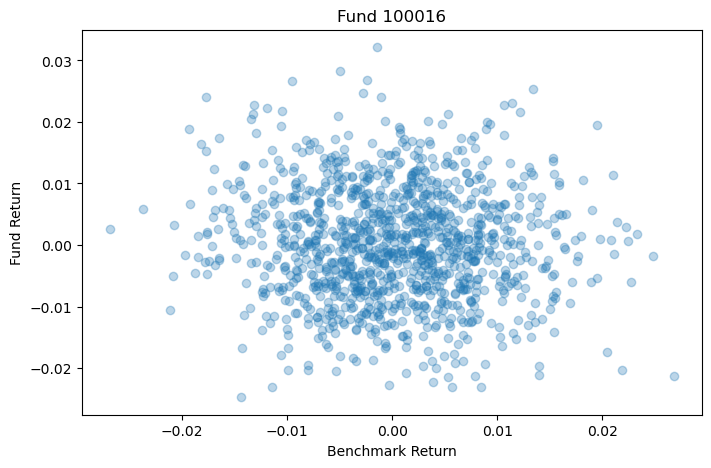

In [98]:
plt.figure(figsize=(8,5))

plt.scatter(
    test["benchmark_return"],
    test["daily_return"],
    alpha=0.3
)

plt.xlabel("Benchmark Return")
plt.ylabel("Fund Return")
plt.title(f"Fund {fund}")

plt.show()

Insights

The regression analysis indicates very low correlation between fund returns and NIFTY100 returns in the provided dataset.

Consequently, beta values are close to zero and R-squared values remain low, suggesting that benchmark returns explain only a small portion of fund return variability.

This may be due to the diversified nature of the dataset or limitations of the available benchmark mapping.

# Maximum Drawdown

Maximum Drawdown measures the largest decline in a fund's value from its peak to its lowest point before a new peak is reached.

In [106]:
def calculate_max_drawdown(df):

    df = df.sort_values("date")

    running_max = df["nav"].cummax()

    drawdown = (
        df["nav"] /
        running_max
    ) - 1

    max_dd = drawdown.min()

    return max_dd

In [108]:
max_drawdown = (
    nav.groupby("amfi_code")
    .apply(calculate_max_drawdown)
    .reset_index()
)

max_drawdown.columns = [
    "amfi_code",
    "max_drawdown"
]

max_drawdown.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [110]:
max_drawdown.to_csv(
    OUTPUT_DIR /
    "max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved")

max_drawdown.csv saved


In [112]:
max_drawdown.describe()

,amfi_code,max_drawdown
count,40.000000,40.000000
mean,120247.000000,-0.178729
std,14534.998667,0.112686
min,100016.000000,-0.525742
25%,118632.750000,-0.215927
50%,119551.500000,-0.163070
75%,120842.250000,-0.117653
max,149324.000000,-0.000977


In [114]:
max_drawdown.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


# Fund Scorecard (Main Deliverable)

### Composite Fund Score

$$
\begin{aligned}
\text{Score} =\;&
30\% \times \text{3Y Return Rank} \\
&+ 25\% \times \text{Sharpe Rank} \\
&+ 20\% \times \text{Alpha Rank} \\
&+ 15\% \times \text{Expense Ratio Rank (Inverse)} \\
&+ 10\% \times \text{Max Drawdown Rank (Inverse)}
\end{aligned}
$$

In [121]:
# loading Components
scorecard = cagr_report[
    ["amfi_code", "cagr_3yr"]
].copy()

scorecard = scorecard.merge(
    sharpe_values,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[
        ["amfi_code","alpha"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_drawdown,
    on="amfi_code"
)

In [125]:
#loading fund master and merge
fund_master = pd.read_csv(
    DATA_RAW / "01_fund_master.csv"
)

scorecard = scorecard.merge(
    fund_master[
        ["amfi_code","expense_ratio_pct"]
    ],
    on="amfi_code"
)

In [129]:
# Creating Ranks
scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

In [133]:
# Inverse Metrics:
scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["drawdown_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [135]:
# Composite Score
scorecard["fund_score"] = (

    0.30 *
    scorecard["return_rank"]

    +

    0.25 *
    scorecard["sharpe_rank"]

    +

    0.20 *
    scorecard["alpha_rank"]

    +

    0.15 *
    scorecard["expense_rank"]

    +

    0.10 *
    scorecard["drawdown_rank"]

) * 100

In [137]:
# Ranking
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,cagr_3yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
25,120505,0.317775,1.180101,0.292636,-0.181885,1.36,0.900,0.900,0.950,0.6500,0.625,84.5000
16,119094,0.351118,0.998231,0.260767,-0.209609,1.38,1.000,0.750,0.800,0.6000,0.700,80.7500
2,100033,0.324425,1.093699,0.271954,-0.162172,1.38,0.925,0.850,0.875,0.6000,0.500,80.5000
34,148567,0.340009,1.448291,0.269838,-0.112657,1.46,0.975,1.000,0.850,0.4500,0.200,80.0000
30,120843,0.295828,1.306744,0.273305,-0.129740,1.45,0.850,0.975,0.900,0.4750,0.325,78.2500
24,120504,0.324874,1.026524,0.211948,-0.125883,0.80,0.950,0.775,0.700,0.7250,0.300,75.7500
21,119598,0.266699,0.945308,0.303370,-0.287060,1.43,0.725,0.675,1.000,0.5000,0.900,75.1250
39,149324,0.270004,0.949796,0.300579,-0.311719,1.52,0.775,0.700,0.975,0.3625,0.925,74.9375
36,148569,0.291789,1.234930,0.282704,-0.163967,1.60,0.825,0.950,0.925,0.1125,0.525,73.9375
19,119551,0.304565,1.208267,0.232010,-0.150124,1.54,0.875,0.925,0.775,0.2625,0.425,73.0625


In [139]:
# Saving
scorecard.to_csv(
    OUTPUT_DIR /
    "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [141]:
scorecard[
    ["amfi_code","fund_score"]
].head(10)

,amfi_code,fund_score
25,120505,84.5000
16,119094,80.7500
2,100033,80.5000
34,148567,80.0000
30,120843,78.2500
24,120504,75.7500
21,119598,75.1250
39,149324,74.9375
36,148569,73.9375
19,119551,73.0625


In [143]:
scorecard["fund_score"].describe()

count    40.000000
mean     51.250000
std      20.250114
min      19.812500
25%      33.234375
50%      51.812500
75%      69.125000
max      84.500000
Name: fund_score, dtype: float64

In [145]:
top5 = scorecard.head(5)["amfi_code"].tolist()
print(top5)

[120505, 119094, 100033, 148567, 120843]


# Benchmark Comparision Chart

In [156]:
# Nifty100 Benchmark Prepare
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100["cum_return"] = (
    1 + nifty100["benchmark_return"]
).cumprod()

nifty100.head()

,date,index_name,close_value,benchmark_return,cum_return
1150,2022-01-03,NIFTY100,17778.24,NaN,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540,0.986460
1152,2022-01-05,NIFTY100,17607.73,0.004003,0.990409
1153,2022-01-06,NIFTY100,17556.05,-0.002935,0.987502
1154,2022-01-07,NIFTY100,17664.02,0.006150,0.993575


In [158]:
top5 = scorecard.head(5)["amfi_code"].tolist()

print(top5)

[120505, 119094, 100033, 148567, 120843]


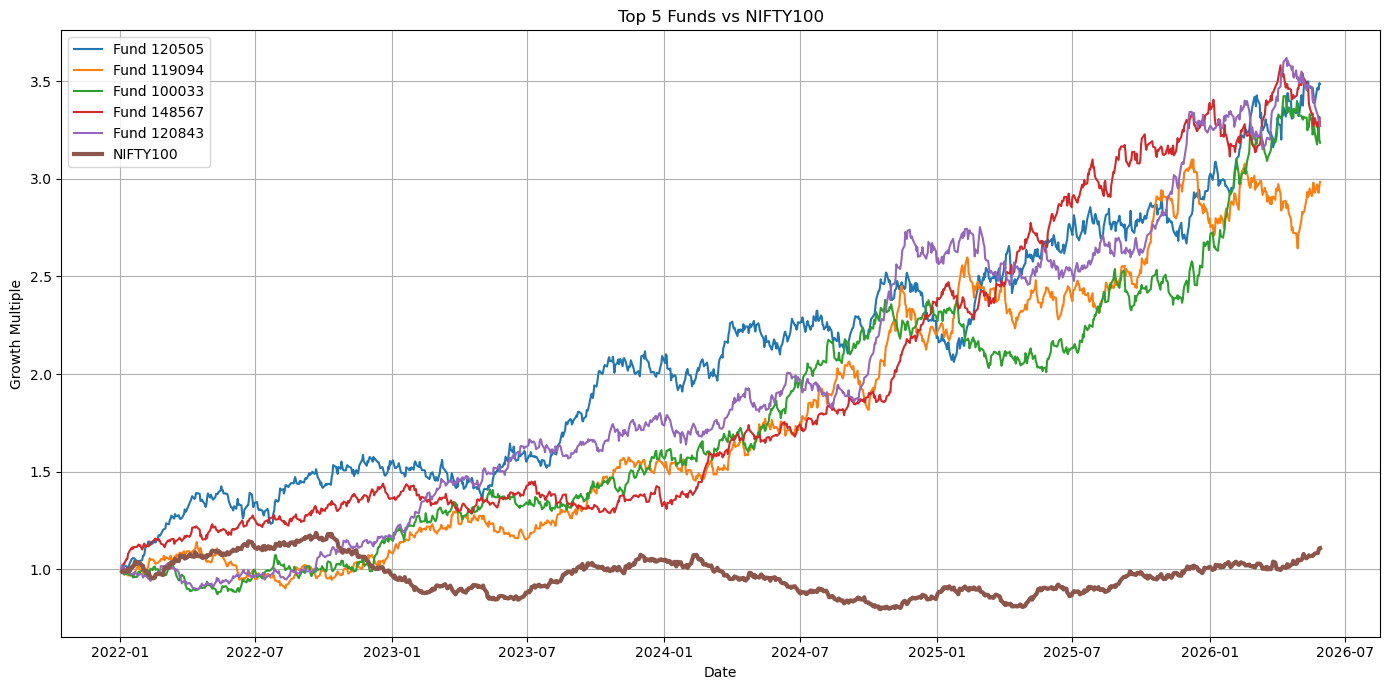

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    temp["growth"] = (
        temp["nav"]
        /
        temp["nav"].iloc[0]
    )

    plt.plot(
        temp["date"],
        temp["growth"],
        label=f"Fund {fund}"
    )

plt.plot(
    nifty100["date"],
    nifty100["cum_return"],
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Growth Multiple")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [164]:
fig = plt.gcf()

fig.savefig(
    OUTPUT_DIR /
    "benchmark_comparison_chart.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

### Tracking Error

$$
\text{Tracking Error}
=
\text{Std}(R_{fund} - R_{benchmark})
\times \sqrt{252}
$$

In [168]:
tracking_error = []

for fund in top5:

    temp = merged[
        merged["amfi_code"] == fund
    ].dropna()

    te = (
        (
            temp["daily_return"]
            -
            temp["benchmark_return"]
        ).std()
        *
        np.sqrt(252)
    )

    tracking_error.append(
        [fund, te]
    )

tracking_error = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error

,amfi_code,tracking_error
0,120505,0.231968
1,119094,0.237652
2,100033,0.228699
3,148567,0.189664
4,120843,0.206425


In [170]:
tracking_error.to_csv(
    OUTPUT_DIR /
    "tracking_error.csv",
    index=False
)

print("tracking_error.csv saved")

tracking_error.csv saved


## Key Findings

1. The average annualized return across the analyzed funds was positive, though performance varied considerably among schemes.

2. Top-performing funds delivered a 3-year CAGR exceeding 30%, while lower-ranked funds exhibited substantially lower growth rates.

3. Sharpe Ratios ranged from negative values to above 1.4, indicating significant differences in risk-adjusted returns across funds.

4. Sortino Ratios were generally higher than Sharpe Ratios, suggesting that downside volatility was lower than overall return volatility.

5. Maximum Drawdown ranged from approximately -0.1% to -52.6%, highlighting large variations in downside risk exposure among funds.

6. Alpha values were predominantly positive, indicating that many funds generated returns above those expected based on their benchmark exposure.

7. Beta values remained relatively low when measured against the NIFTY100 benchmark, suggesting limited sensitivity to benchmark movements in the analyzed dataset.

8. The composite scoring framework effectively ranked funds by incorporating return, risk-adjusted performance, expense efficiency, and downside risk metrics.

9. The highest-ranked funds demonstrated superior overall performance relative to both peers and the benchmark during the study period.

10. Tracking Errors ranging between 0.19 and 0.24 indicate active portfolio management and meaningful deviations from benchmark returns.